In [ ]:
import warnings
warnings.filterwarnings('ignore')

# data imports
import pandas as pd
import numpy as np
from plotnine import *

# modeling imports
from sklearn.linear_model import LinearRegression, LassoCV, RidgeCV # Linear Regression Model
from sklearn.preprocessing import StandardScaler #Z-score variables
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error, mean_absolute_error #model evaluation
from sklearn.model_selection import train_test_split, KFold, LeaveOneOut
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelBinarizer
from sklearn.compose import ColumnTransformer

# pipeline imports
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.compose import make_column_transformer
from sklearn.model_selection import train_test_split
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LassoCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import NearestNeighbors
from sklearn.naive_bayes import GaussianNB

In [ ]:
film = pd.read_csv('/content/MasterFilmDataWithOverallRatings.csv')


In [ ]:
film['Writers'] = film['TomatoesWriters'].str.split("&")
film['Producers'] = film['TomatoesProducers'].str.split("&")
film['Tgenres'] = film['TomatoesGenres'].str.split("&")
film['Directors'] = film['MetacriticDirectors'].str.split("|")
film['Actors'] = film['MetacriticActors'].str.split("|")
film['Mgenres'] = film['MetacriticGenres'].str.split("|")

film = film.explode('Writers')
film = film.explode('Producers')
film = film.explode('Tgenres')

film = film.explode('Directors')
film = film.explode('Actors')
film = film.explode('Mgenres')

film.dropna(inplace = True)
film.reset_index(inplace = True)

In [ ]:
df1 = film.groupby('Writers').agg(filmcountW=('MetacriticCriticRating', 'count')).reset_index()
df2 = film.groupby('Directors').agg(filmcountD=('MetacriticCriticRating', 'count')).reset_index()
df3 = film.groupby('Producers').agg(filmcountP=('MetacriticCriticRating', 'count')).reset_index()
df4 = film.groupby('Actors').agg(filmcountA=('MetacriticCriticRating', 'count')).reset_index()

In [ ]:
nd1=df1.join(df2)
nd2=df3.join(df4)
new_film=nd1.join(nd2)

In [ ]:
new_film.rename(columns={'Writers': 'WriterName'}, inplace=True)
new_film.rename(columns={'Directors': 'DirectorName'}, inplace=True)
new_film.rename(columns={'Producers': 'ProducerName'}, inplace=True)

new_film.rename(columns={'Actors': 'ActorName'}, inplace=True)

In [ ]:
new_film = new_film.join(film)

In [ ]:
new_film.dropna(inplace = True)
new_film.reset_index(inplace = True)

In [ ]:
df_filtered = new_film[(new_film['filmcountW'] > 3) & (new_film['filmcountD'] > 3) & (new_film['filmcountP'] > 3) & (new_film['filmcountA'] > 3)]

In [ ]:


df_filtered = df_filtered[df_filtered['WriterName'].str.match('^[A-Za-z]')]
df_filtered = df_filtered[df_filtered['ProducerName'].str.match('^[A-Za-z]')]
df_filtered = df_filtered[df_filtered['Tgenres'].str.match('^[A-Za-z]')]

df_filtered = df_filtered[df_filtered['DirectorName'].str.match('^[A-Za-z]')]
df_filtered = df_filtered[df_filtered['ActorName'].str.match('^[A-Za-z]')]
df_filtered = df_filtered[df_filtered['Mgenres'].str.match('^[A-Za-z]')]

df_filtered.reset_index(drop=True, inplace=True)

In [ ]:
my_list = []
for name in df_filtered['WriterName']:
    if name in df_filtered['DirectorName'].values:
        my_list.append(1)
    else:
        my_list.append(0)

In [ ]:
df_filtered['WD'] = my_list

In [ ]:
df_filtered.dropna(inplace = True)
df_filtered.reset_index(drop=True, inplace=True)

In [ ]:
df_filtered.describe()

,level_0,filmcountW,filmcountD,filmcountP,filmcountA,index,MetacriticYear,MetacriticMonth,MetacriticDay,MetacriticCriticRating,...,NashInternationalBoxOffice,NashInflationAdjustedDomesticBoxOffice,NashYear,TicketsSold,PercentViewed,PercentViewedForMpaaRating,ViewingRating,OverallRating,NormalizedOverallRating,WD
count,3212.000000,3212.000000,3212.000000,3212.000000,3212.000000,3212.000000,3212.000000,3212.000000,3212.000000,3212.000000,...,3.212000e+03,3.212000e+03,3212.000000,3.212000e+03,3212.000000,3212.000000,3212.000000,3212.000000,3212.000000,3212.000000
mean,2550.630137,247.754047,408.103362,221.522727,97.342777,6.087796,2002.713574,5.598381,19.744707,73.354608,...,4.982054e+08,6.607043e+08,2002.713574,7.347669e+07,0.259912,0.278306,30.222790,2251.386939,25.757037,0.230697
std,1460.464367,760.998040,1231.702777,776.998081,246.830826,4.436592,5.660885,1.404481,5.513118,14.243545,...,7.185275e+07,1.561342e+08,5.660885,2.147944e+07,0.106917,0.111802,11.739512,1134.928369,12.485635,0.421345
min,40.000000,4.000000,4.000000,4.000000,4.000000,1.000000,1977.000000,2.000000,3.000000,35.000000,...,2.515307e+08,4.916488e+08,1977.000000,5.361492e+07,0.174771,0.211054,23.161163,810.640722,9.907000,0.000000
25%,1282.750000,18.000000,20.000000,16.000000,12.000000,3.000000,2003.000000,5.000000,19.000000,75.000000,...,4.687283e+08,5.636325e+08,2003.000000,6.310603e+07,0.217526,0.242656,26.479443,1985.958200,22.837000,0.000000
50%,2538.500000,60.000000,80.000000,44.000000,27.000000,3.000000,2004.000000,5.000000,19.000000,75.000000,...,4.940277e+08,6.515370e+08,2004.000000,7.105092e+07,0.242656,0.242656,26.479443,1985.958200,22.837000,0.000000
75%,3815.250000,181.250000,320.000000,149.250000,80.000000,9.250000,2004.000000,6.000000,19.000000,83.000000,...,4.940277e+08,6.515370e+08,2004.000000,7.105092e+07,0.242656,0.249672,27.216112,2258.937306,25.840000,0.000000
max,5076.000000,16048.000000,45634.000000,23787.000000,3324.000000,15.000000,2009.000000,12.000000,30.000000,94.000000,...,7.423681e+08,1.506917e+09,2009.000000,2.067256e+08,0.942836,0.942836,100.000000,9000.000000,100.000000,1.000000


LASSO Model

In [ ]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LassoCV
from sklearn.model_selection import train_test_split

# FEATURES
predictors = [
    "WD",
    "Mgenres",
    "Tgenres",
    "NashSource",
    "NashProductionMethod",
    "NashProductionBudget"
]

countin = ["WD", "NashProductionBudget"]
categorical_cols = ["Mgenres", "Tgenres", "NashSource", "NashProductionMethod"]

X = df_filtered[predictors]
y = df_filtered["MetacriticCriticRating"]

# TRAIN / TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# PREPROCESSOR
z = make_column_transformer(
    (StandardScaler(), countin),
    (OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), categorical_cols),
    remainder='passthrough'
)

# MODEL PIPELINE
pipe = Pipeline([
    ("preprocess", z),
    ("lasso", LassoCV())
])

# FIT MODEL
pipe.fit(X_train, y_train)

# PREDICTIONS
y_pred_train = pipe.predict(X_train)
y_pred_test = pipe.predict(X_test)

In [ ]:
# assess
print("Train MSE : ", mean_squared_error(y_train, y_pred_train))
print("Train MAE : ", mean_absolute_error(y_train, y_pred_train))
print("Train MAPE: ", mean_absolute_error(y_train, y_pred_train) / y_train.mean())  # Corrected MAPE calculation
print("Train R2  : ", r2_score(y_train, y_pred_train))

print("Test MSE  : ", mean_squared_error(y_test, y_pred_test))
print("Test MAE  : ", mean_absolute_error(y_test, y_pred_test))
print("Test MAPE : ", mean_absolute_error(y_test, y_pred_test) / y_test.mean())  # Corrected MAPE calculation
print("Test R2   : ", r2_score(y_test, y_pred_test))

Train MSE :  25.213820761439468
Train MAE :  2.5981875256843785
Train MAPE:  0.035407527125504844
Train R2  :  0.8763851402815308
Test MSE  :  18.952463163822628
Test MAE  :  2.3551180278006867
Test MAPE :  0.032149563549579464
Test R2   :  0.9043707530584717


In [ ]:
# Access the Lasso model from the pipeline
lasso_model = pipe.named_steps["lasso"]

# Get feature names after one-hot encoding
encoded_cols = z.named_transformers_['onehotencoder'].get_feature_names_out(input_features=categorical_cols)
feature_names = list(encoded_cols) + countin

# Get the coefficients
coefficients = lasso_model.coef_

# Create a dictionary to map feature names to coefficients
coefficients_dict = dict(zip(feature_names, coefficients))

# Print the coefficients
for feature, coef in coefficients_dict.items():
    print(f"{feature}: {coef}")

Mgenres_Adventure: 0.14263081222235102
Mgenres_Animation: 8.510613156023421
Mgenres_Comedy: 0.10580722893498044
Mgenres_Crime: -0.021767234971461217
Mgenres_Drama: 0.09169128651894254
Mgenres_Family: 0.9450499557782397
Mgenres_Fantasy: 0.4475217824358222
Mgenres_History: 0.06326058427404943
Mgenres_Sci-Fi: -1.286801057303213
Mgenres_Thriller: -0.0
Tgenres_Adventure: -2.494535696662721
Tgenres_Animation: -0.5816520344140633
Tgenres_Comedy: 2.965666808471558
Tgenres_Drama: 1.2532266194010808
Tgenres_Fantasy: 1.263792214260705
Tgenres_Kids and family: -7.478915920601953
Tgenres_Mystery and thriller: 1.3569255337208577
Tgenres_Sci-fi: 1.608005573378956
NashSource_Based on Fiction Book/Short Story: 0.0
NashSource_Based on Religious Text: -1.1670397578078768
NashSource_Based on TV: 33.55654327141902
NashSource_Based on Theme Park Ride: -0.0
NashSource_Original Screenplay: -22.599242447504448
NashProductionMethod_Digital Animation: -34.384829233162755
NashProductionMethod_Live Action: 36.7844

In [ ]:
# One-hot encode X_train
encoder_X = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')
X_train_encoded = encoder_X.fit_transform(X_train)

# One-hot encode y_train
encoder_y = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')
y_train_encoded = encoder_y.fit_transform(y_train.to_numpy().reshape(-1, 1))

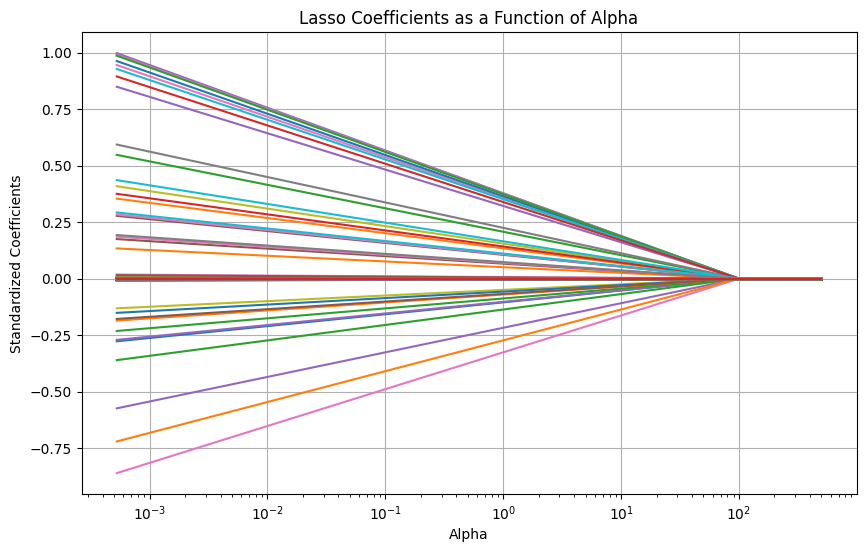

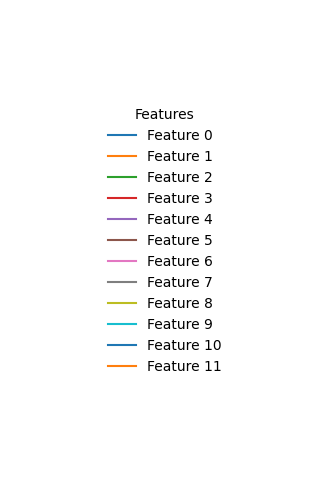

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso

alphas = np.linspace(0.0005269538735017189, 500, 6)
lasso = Lasso(max_iter=10000)

coefs = []

for a in alphas:
    lasso.set_params(alpha=a)
    lasso.fit(X_train_encoded, y_train_encoded)
    coefs.append(lasso.coef_)

# LASSO PLOT
plt.figure(figsize=(10, 6))

plt.xscale('log')

for i in range(len(coefs[0])):
    plt.plot(alphas, [coef[i] for coef in coefs], label=f'Feature {i}')

plt.xlabel('Alpha')
plt.ylabel('Standardized Coefficients')
plt.title('Lasso Coefficients as a Function of Alpha')
plt.grid(True)

plt.show()


# KEY PLOT
plt.figure(figsize=(4, 6))

# create fake lines just for legend
for i in range(len(coefs[0])):
    plt.plot([], [], label=f'Feature {i}')

plt.legend(title="Features", loc="center", frameon=False)
plt.axis("off")

plt.show()

Recommendation Model

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neighbors import NearestNeighbors
from sklearn.pipeline import Pipeline
import pandas as pd
import numpy as np

# FEATURES

feat = [
    'DirectorName',
    'WriterName',
    'Mgenres',
    'NashYear',
    'NashRunningTimeMinutes',
    'NashDistributor',
    'NashMpaaRating'
]

c = ['NashYear', 'NashRunningTimeMinutes']
cc = [
    'DirectorName',
    'WriterName',
    'Mgenres',
    'NashDistributor',
    'NashMpaaRating'
]

# Clean data for recommendation

df_clean = df_filtered.drop_duplicates(subset=["MetacriticName"]).reset_index(drop=True)


# PREPROCESSING PIPELINE

z = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), c),
        ('cat', OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore'), cc)
    ],
    remainder='drop'
)


# NEAREST NEIGHBORS MODEL

nn_model = NearestNeighbors(n_neighbors=4, metric='cosine')

pipe = Pipeline([
    ("z", z),
    ("model", nn_model)
])


# FIT MODEL

pipe.fit(df_clean[feat])

X_transformed = pipe.named_steps["z"].transform(df_clean[feat])

distances, indices = pipe.named_steps["model"].kneighbors(X_transformed)


# REMOVE SELF-NEIGHBORS

clean_indices = []

for i, neighbors in enumerate(indices):
    clean = [n for n in neighbors if n != i]
    clean_indices.append(clean[:5])  # keep top 5


# BUILD OUTPUT DATAFRAME

df_recommendations = df_clean[feat].copy()
df_recommendations["neighbors"] = clean_indices


# EXAMPLE OUTPUT FUNCTION

def get_recommendations(movie_index, top_n=5):
    movie = df_clean.iloc[movie_index]["MetacriticName"]
    neighbor_ids = clean_indices[movie_index][:top_n]

    print(f"\n🎬 Recommendations for: {movie}\n")

    for idx in neighbor_ids:
        print("-", df_clean.iloc[idx]["MetacriticName"])


# TEST EXAMPLE

get_recommendations(0)


🎬 Recommendations for: The Dark Knight

- Transformers: Revenge of the Fallen
- The Lord of the Rings: The Return of the King
- Star Wars: Episode III - Revenge of the Sith


In [ ]:
# METRICS STORAGE
df = df_clean.reset_index(drop=True)
avg_distances = []

year_scores = []
runtime_scores = []

genre_scores = []
director_scores = []
writer_scores = []
distributor_scores = []
rating_scores = []

# LOOP THROUGH EACH MOVIE
for i, neighbors in enumerate(indices):

    # Distance
    avg_distances.append(np.mean(distances[i]))

    # Base values
    base_year = df.loc[i, "NashYear"]
    base_runtime = df.loc[i, "NashRunningTimeMinutes"]

    base_genre = df.loc[i, "Mgenres"]
    base_director = df.loc[i, "DirectorName"]
    base_writer = df.loc[i, "WriterName"]
    base_distributor = df.loc[i, "NashDistributor"]
    base_rating = df.loc[i, "NashMpaaRating"]

    # Numeric similarity (normalized difference)
    year_sim = np.mean([
        1 - abs(df.loc[j, "NashYear"] - base_year) / df["NashYear"].max()
        for j in neighbors
    ])
    year_scores.append(year_sim)

    runtime_sim = np.mean([
        1 - abs(df.loc[j, "NashRunningTimeMinutes"] - base_runtime) / df["NashRunningTimeMinutes"].max()
        for j in neighbors
    ])
    runtime_scores.append(runtime_sim)

    # Categorical similarity
    genre_scores.append(np.mean([df.loc[j, "Mgenres"] == base_genre for j in neighbors]))
    director_scores.append(np.mean([df.loc[j, "DirectorName"] == base_director for j in neighbors]))
    writer_scores.append(np.mean([df.loc[j, "WriterName"] == base_writer for j in neighbors]))
    distributor_scores.append(np.mean([df.loc[j, "NashDistributor"] == base_distributor for j in neighbors]))
    rating_scores.append(np.mean([df.loc[j, "NashMpaaRating"] == base_rating for j in neighbors]))


print("Year Similarity:", np.mean(year_scores).round(4))
print("Runtime Similarity:", np.mean(runtime_scores).round(4))
print("Genre Similarity:", np.mean(genre_scores).round(4))
print("Director Similarity:", np.mean(director_scores).round(4))
print("Writer Similarity:", np.mean(writer_scores).round(4))
print("Distributor Similarity:", np.mean(distributor_scores).round(4))
print("MPAA Rating Similarity:", np.mean(rating_scores).round(4))
print("Avg Neighbor Distance:", np.mean(avg_distances).round(4))

quality_score = (
    0.15 * np.mean(year_scores) +
    0.15 * np.mean(runtime_scores) +
    0.2 * np.mean(genre_scores) +
    0.15 * np.mean(director_scores) +
    0.1 * np.mean(writer_scores) +
    0.1 * np.mean(distributor_scores) +
    0.1 * np.mean(rating_scores) +
    0.05 * (1 - np.mean(avg_distances))
)

print("\n Overall Recommendation Quality Score:", round(quality_score, 4))

Year Similarity: 0.9979
Runtime Similarity: 0.9279
Genre Similarity: 0.55
Director Similarity: 0.25
Writer Similarity: 0.25
Distributor Similarity: 0.4
MPAA Rating Similarity: 0.8
Avg Neighbor Distance: 0.4733

 Overall Recommendation Quality Score: 0.6077


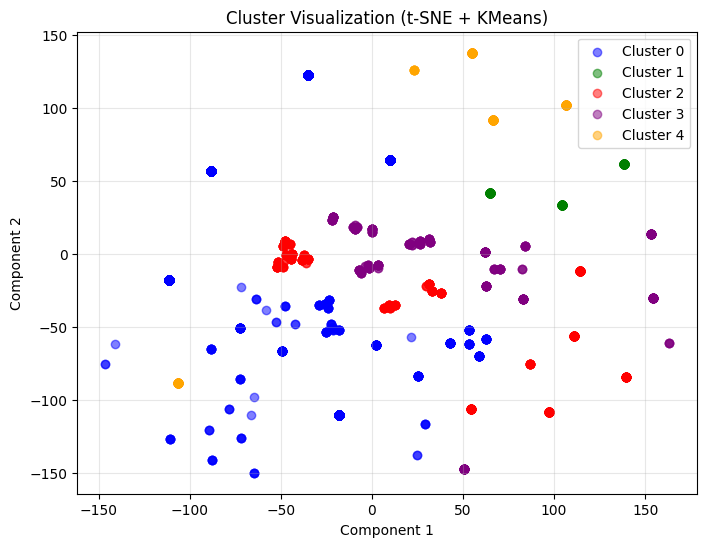

In [ ]:
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt


# Encode categorical features

encoder1 = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')
encoded = encoder1.fit_transform(df_filtered[feat])


# t-SNE reduction

tsne = TSNE(n_components=2, random_state=69)
X_embedded = tsne.fit_transform(encoded)


# KMeans clustering

kmeans = KMeans(n_clusters=5, random_state=69, n_init=10)
clusters = kmeans.fit_predict(encoded)

# Plot clusters

plt.figure(figsize=(8,6))

colors = ['blue', 'green', 'red', 'purple', 'orange']

for cluster_id, color in enumerate(colors):
    plt.scatter(
        X_embedded[clusters == cluster_id, 0],
        X_embedded[clusters == cluster_id, 1],
        c=color,
        alpha=0.5,
        label=f'Cluster {cluster_id}'
    )

plt.title('Cluster Visualization (t-SNE + KMeans)')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.show()

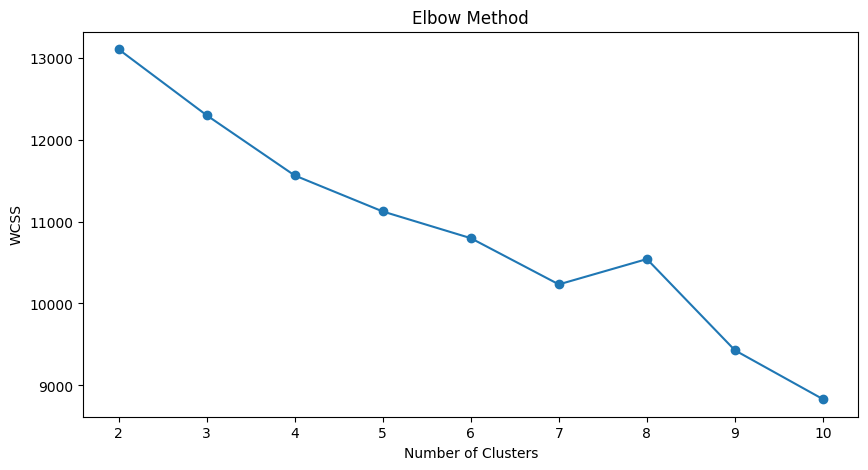

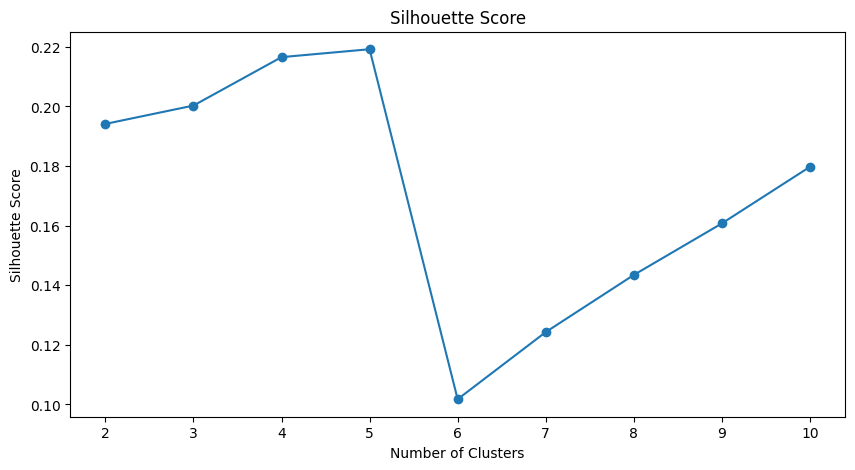

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Initialize lists to store WCSS and silhouette scores
wcss = []
silhouette_scores = []

# Define range of clusters to try
clusters_range = range(2, 11)

# Fit KMeans with different number of clusters and compute WCSS and silhouette scores
for n_clusters in clusters_range:
    kmeans = KMeans(n_clusters=n_clusters, random_state=69)
    kmeans.fit(encoded)
    wcss.append(kmeans.inertia_)  # Within-cluster sum of squares
    silhouette_scores.append(silhouette_score(encoded, kmeans.labels_))

# Plot Elbow Method
plt.figure(figsize=(10, 5))
plt.plot(clusters_range, wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

# Plot Silhouette Score
plt.figure(figsize=(10, 5))
plt.plot(clusters_range, silhouette_scores, marker='o')
plt.title('Silhouette Score')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.show()


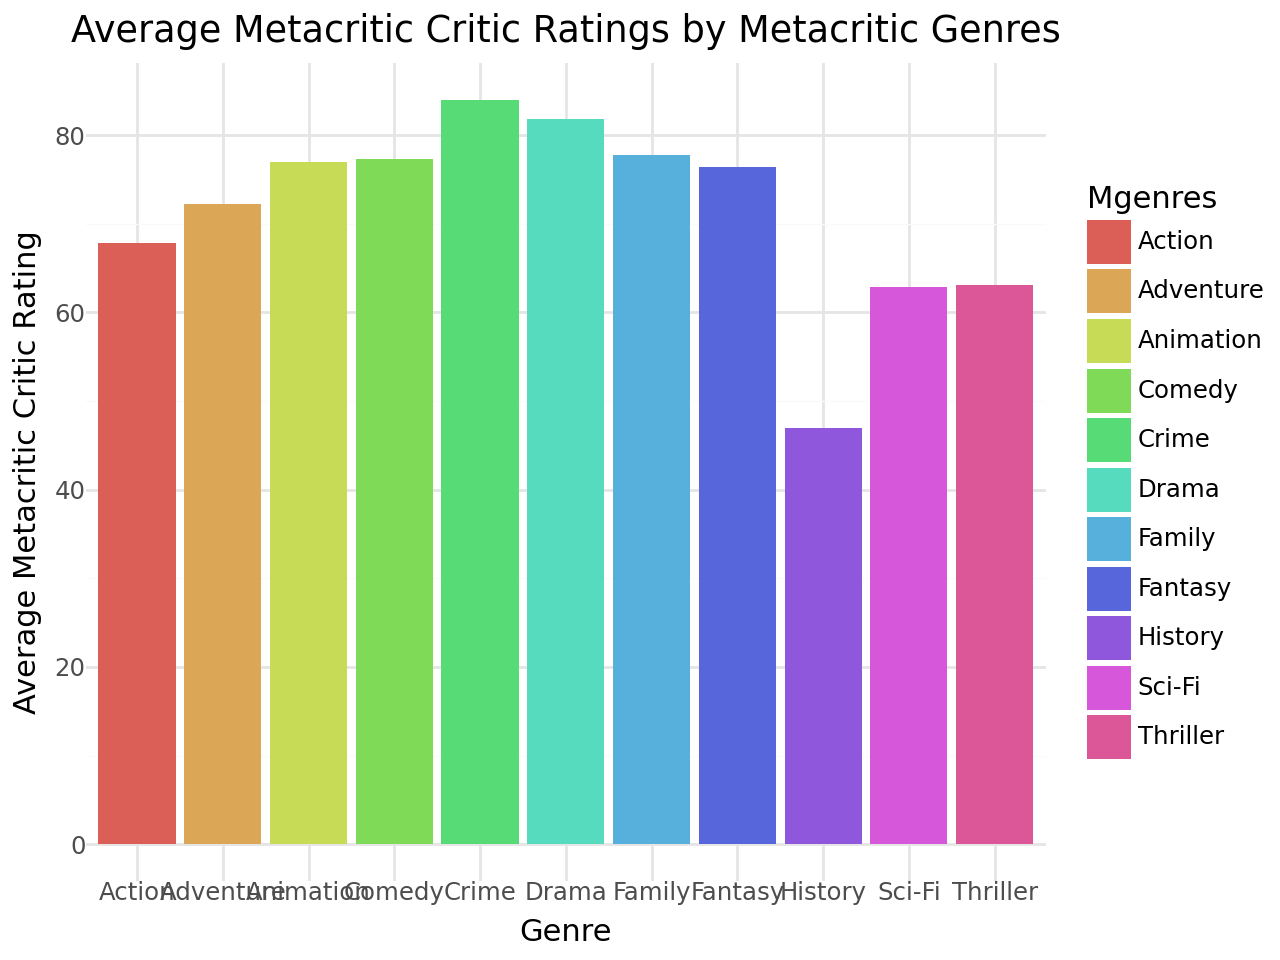

In [ ]:
barplot = ggplot(df_filtered, aes(x='Mgenres', y='MetacriticCriticRating',fill='Mgenres')) + \
          stat_summary(fun_y=np.mean, geom='bar') + \
          theme_minimal() + \
          labs(x="Genre", y="Average Metacritic Critic Rating", title='Average Metacritic Critic Ratings by Metacritic Genres')
barplot

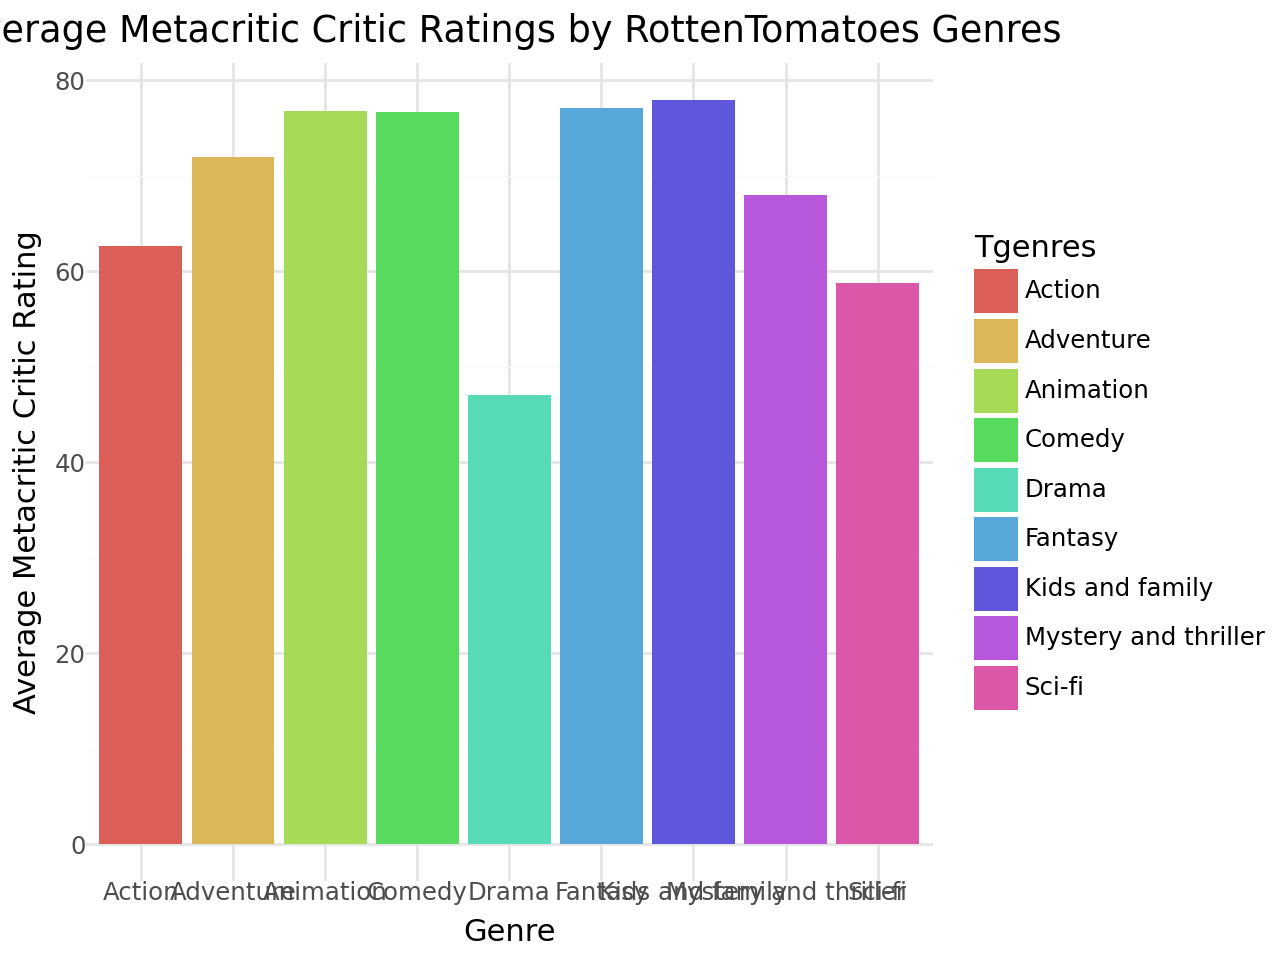

In [ ]:
barplot = ggplot(df_filtered, aes(x='Tgenres', y='MetacriticCriticRating',fill='Tgenres')) + \
          stat_summary(fun_y=np.mean, geom='bar') + \
          theme_minimal() + \
          labs(x="Genre", y="Average Metacritic Critic Rating", title='Average Metacritic Critic Ratings by RottenTomatoes Genres')
barplot

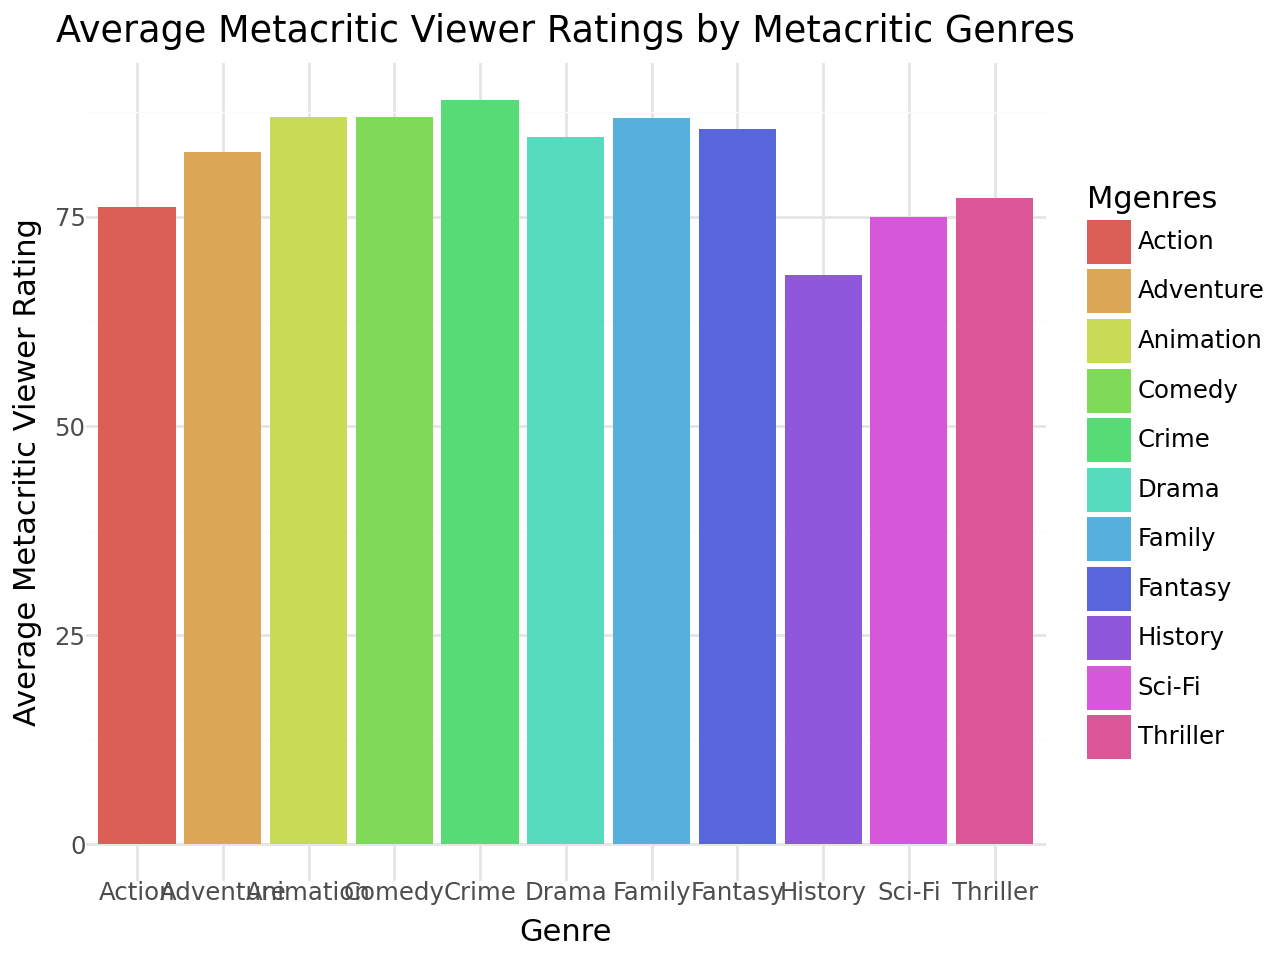

In [ ]:
barplot = ggplot(df_filtered, aes(x='Mgenres', y='MetacriticViewerRating',fill='Mgenres')) + \
          stat_summary(fun_y=np.mean, geom='bar') + \
          theme_minimal() + \
          labs(x="Genre", y="Average Metacritic Viewer Rating", title='Average Metacritic Viewer Ratings by Metacritic Genres')
barplot

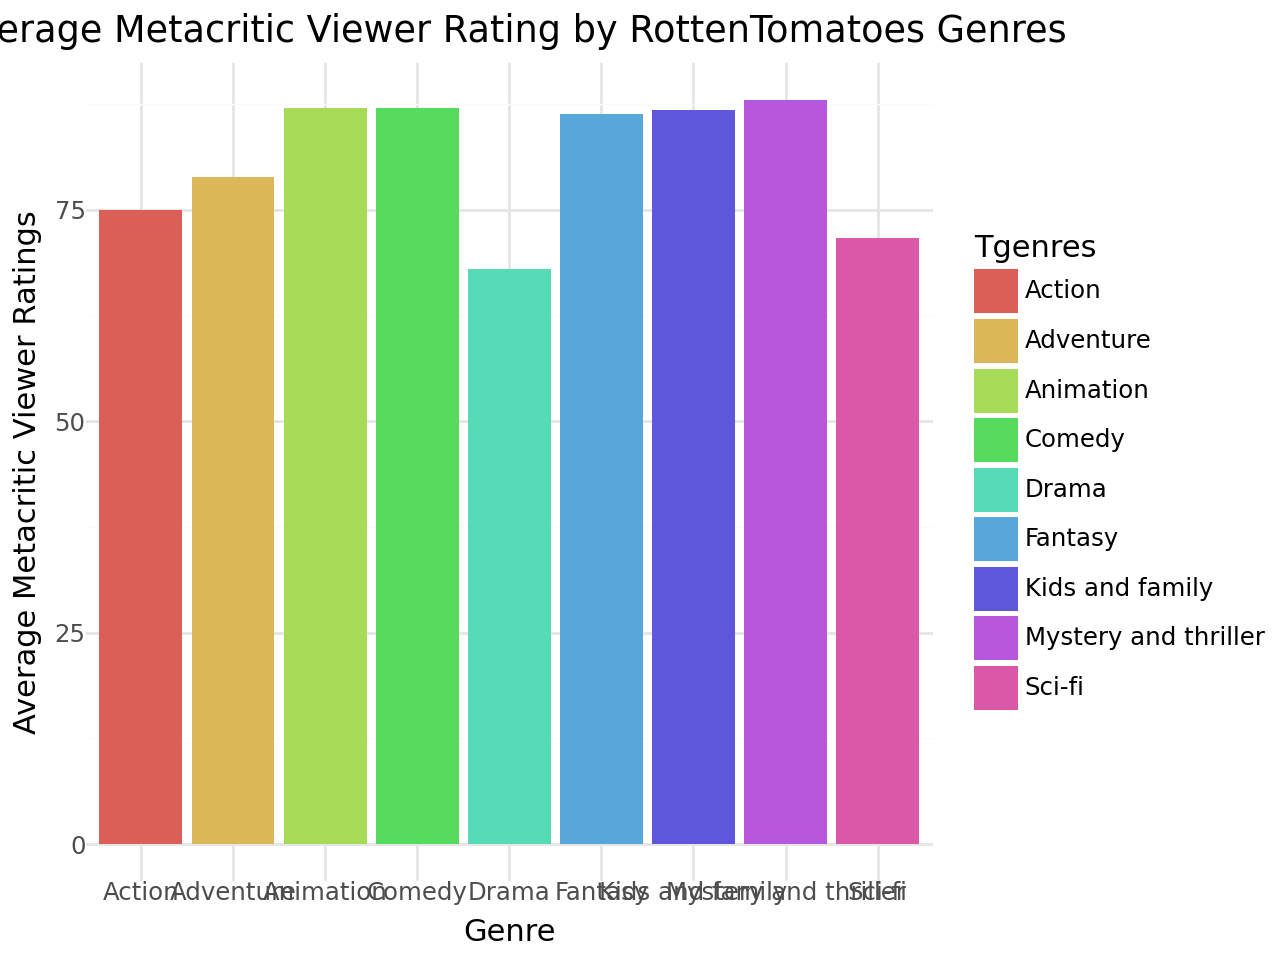

In [ ]:
barplot = ggplot(df_filtered, aes(x='Tgenres', y='MetacriticViewerRating',fill='Tgenres')) + \
          stat_summary(fun_y=np.mean, geom='bar') + \
          theme_minimal() + \
          labs(x="Genre", y="Average Metacritic Viewer Ratings", title='Average Metacritic Viewer Rating by RottenTomatoes Genres')
barplot

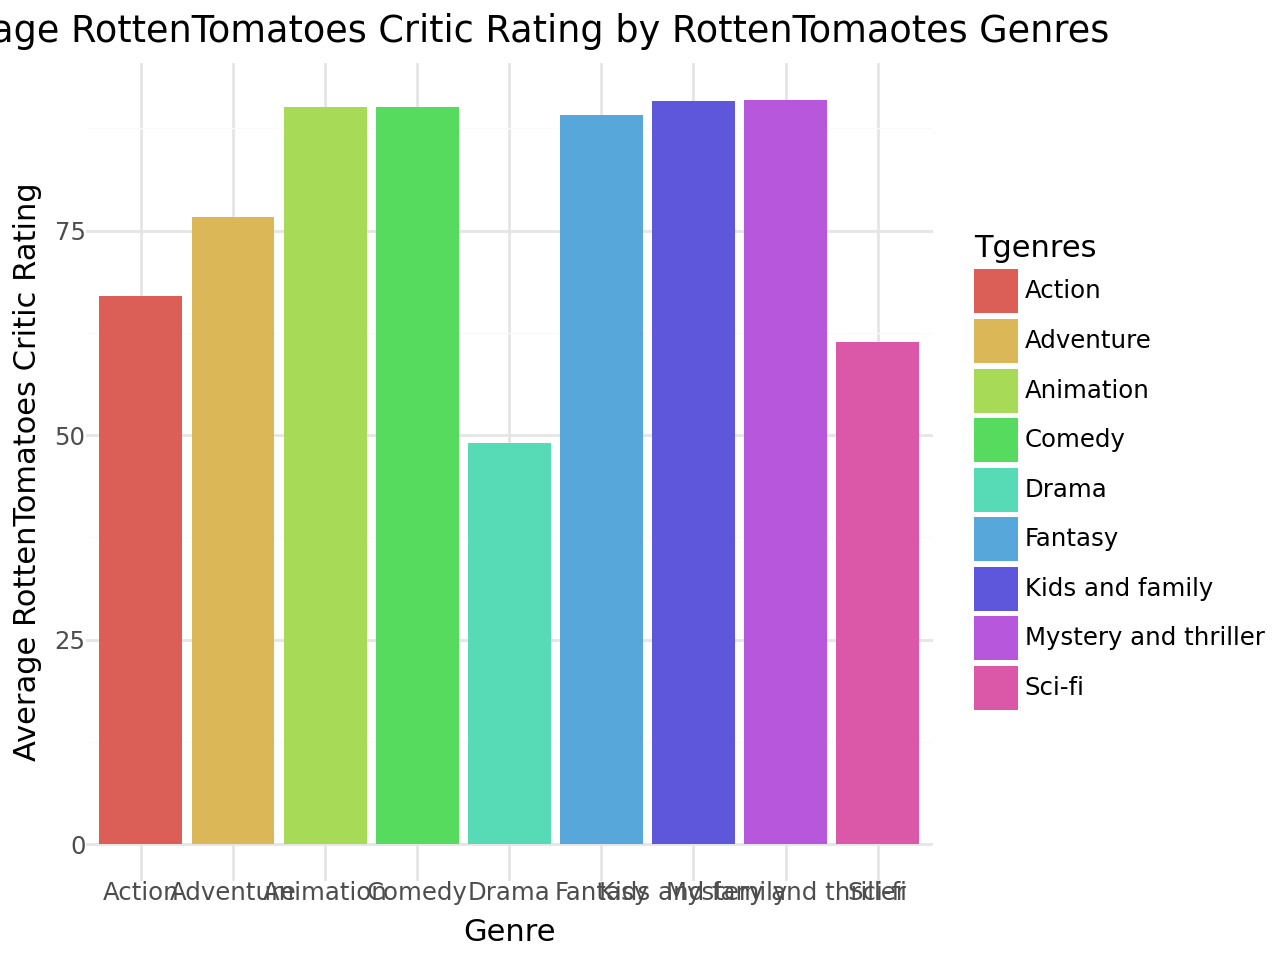

In [ ]:
barplot = ggplot(df_filtered, aes(x='Tgenres', y='TomatoesCriticRating',fill='Tgenres')) + \
          stat_summary(fun_y=np.mean, geom='bar') + \
          theme_minimal() + \
          labs(x="Genre", y="Average RottenTomatoes Critic Rating", title='Average RottenTomatoes Critic Rating by RottenTomaotes Genres')
barplot

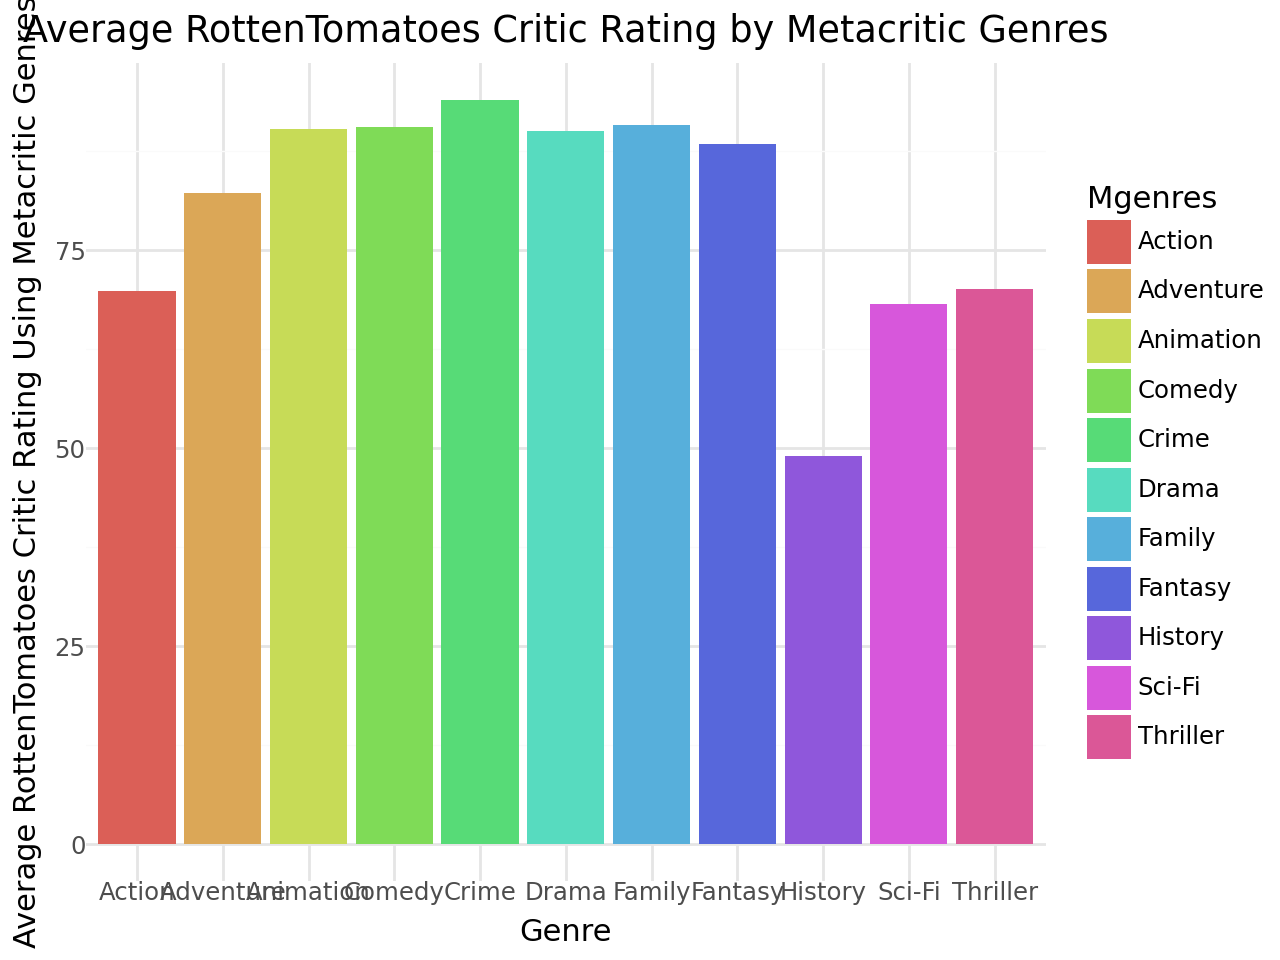

In [ ]:
barplot = ggplot(df_filtered, aes(x='Mgenres', y='TomatoesCriticRating',fill='Mgenres')) + \
          stat_summary(fun_y=np.mean, geom='bar') + \
          theme_minimal() + \
          labs(x="Genre", y="Average RottenTomatoes Critic Rating Using Metacritic Genres", title='Average RottenTomatoes Critic Rating by Metacritic Genres')
barplot

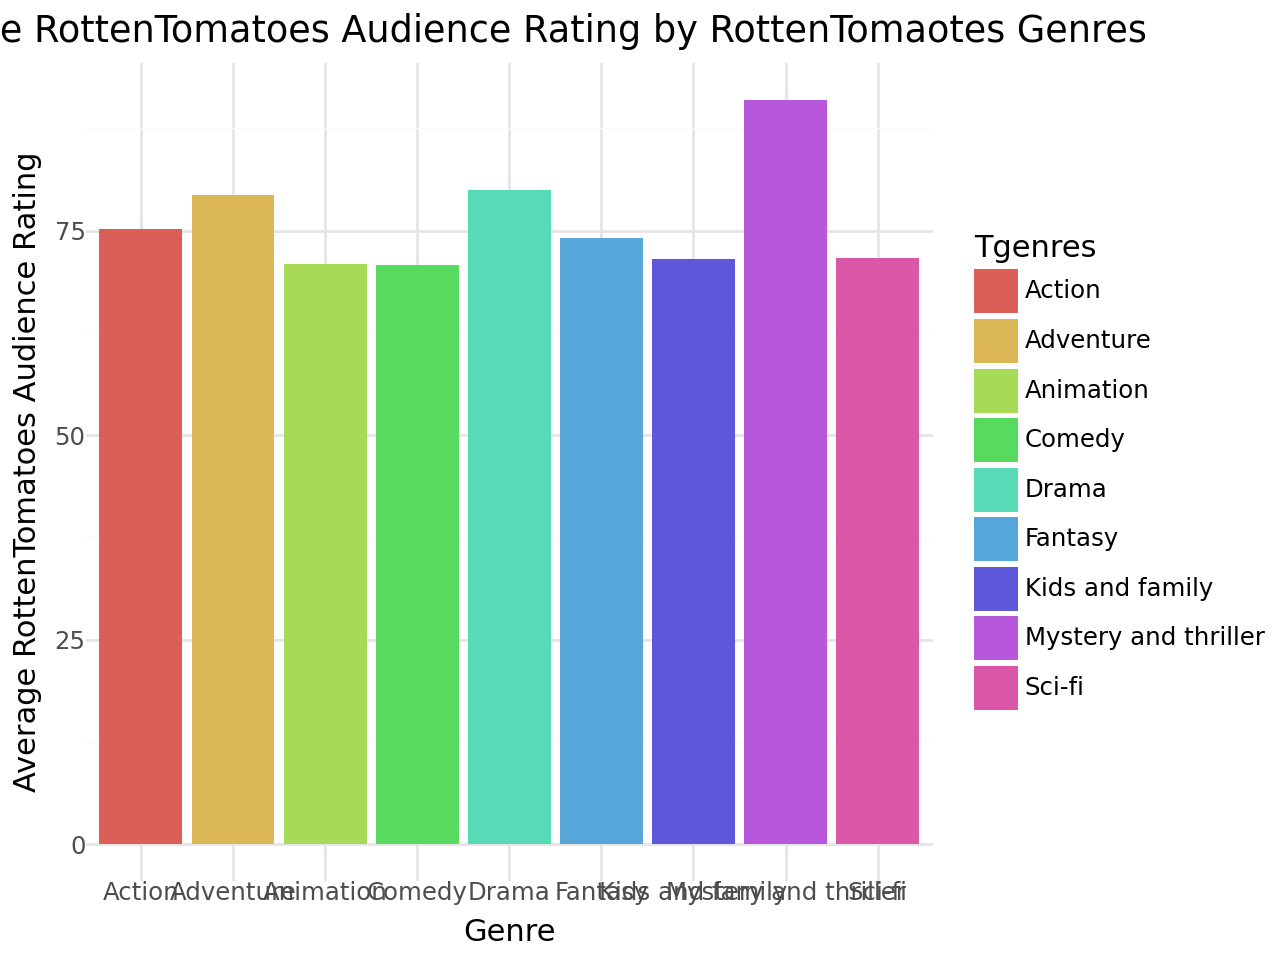

In [ ]:
barplot = ggplot(df_filtered, aes(x='Tgenres', y='TomatoesAudienceRating',fill='Tgenres')) + \
          stat_summary(fun_y=np.mean, geom='bar') + \
          theme_minimal() + \
          labs(x="Genre", y="Average RottenTomatoes Audience Rating", title='Average RottenTomatoes Audience Rating by RottenTomaotes Genres')
barplot

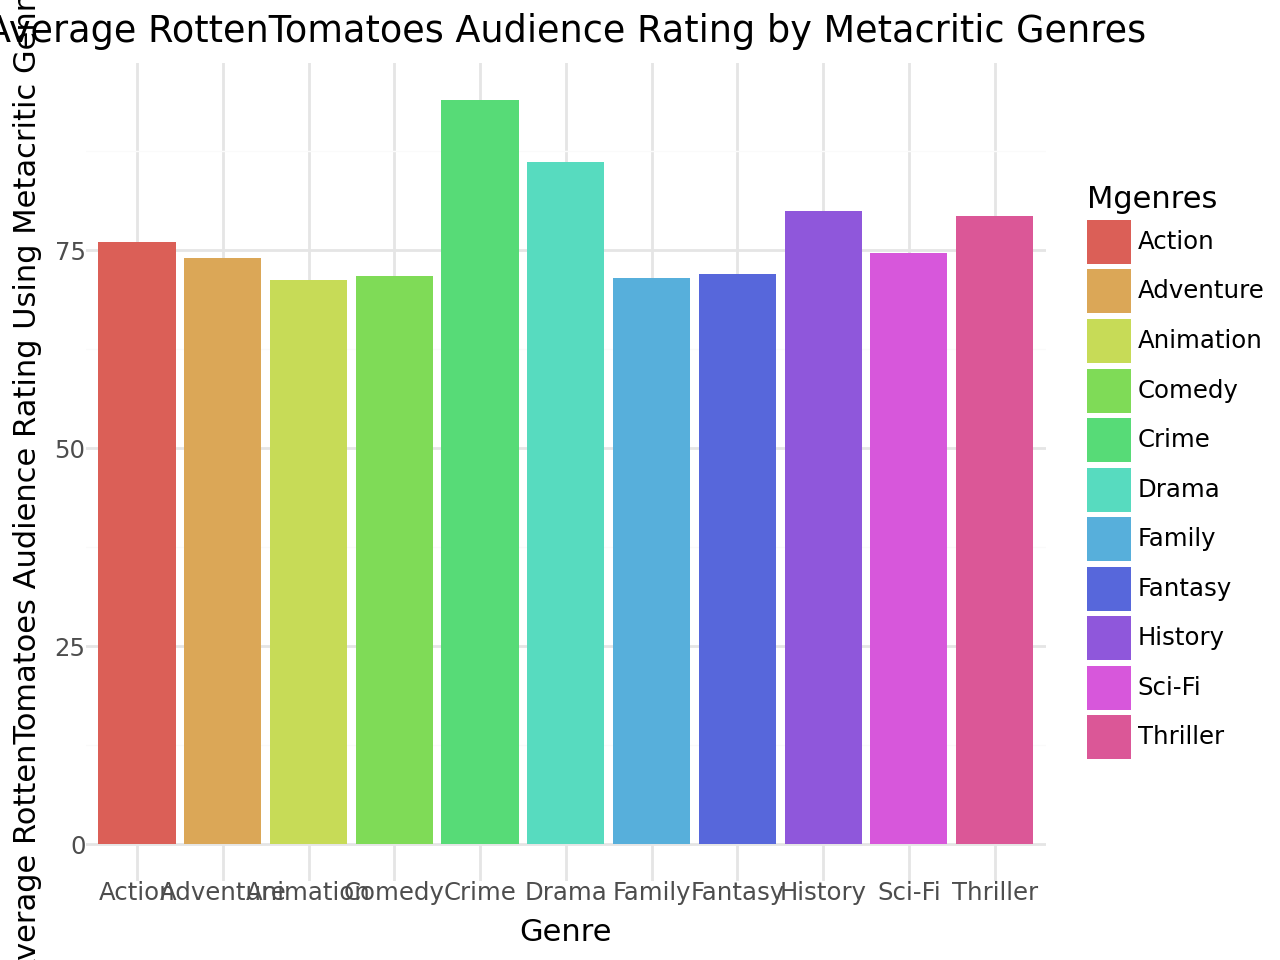

In [ ]:
barplot = ggplot(df_filtered, aes(x='Mgenres', y='TomatoesAudienceRating',fill='Mgenres')) + \
          stat_summary(fun_y=np.mean, geom='bar') + \
          theme_minimal() + \
          labs(x="Genre", y="Average RottenTomatoes Audience Rating Using Metacritic Genres", title='Average RottenTomatoes Audience Rating by Metacritic Genres')
barplot

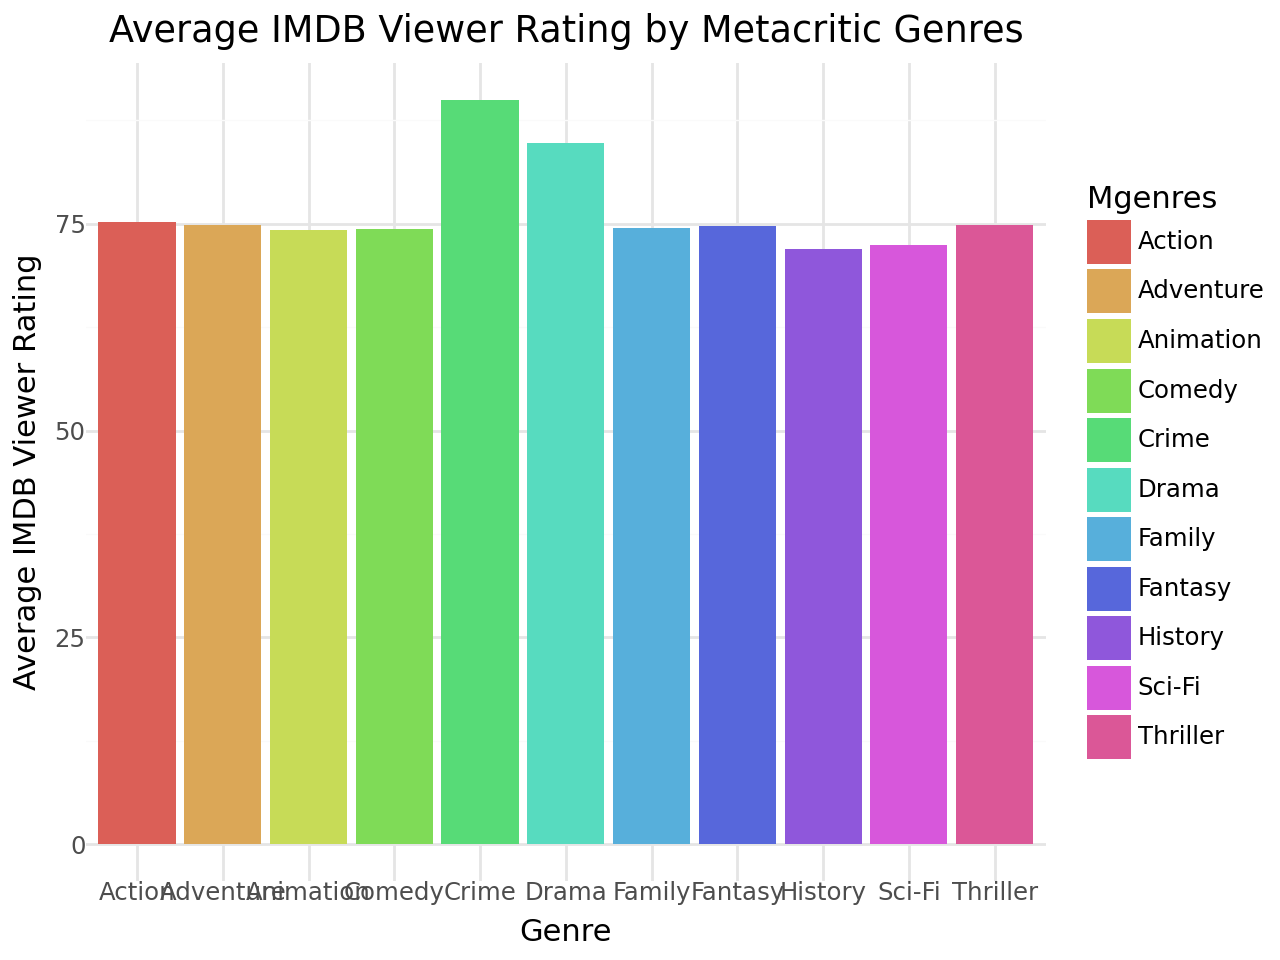

In [ ]:
barplot = ggplot(df_filtered, aes(x='Mgenres', y='ImdbViewerRating',fill='Mgenres')) + \
          stat_summary(fun_y=np.mean, geom='bar') + \
          theme_minimal() + \
          labs(x="Genre", y="Average IMDB Viewer Rating", title='Average IMDB Viewer Rating by Metacritic Genres')
barplot

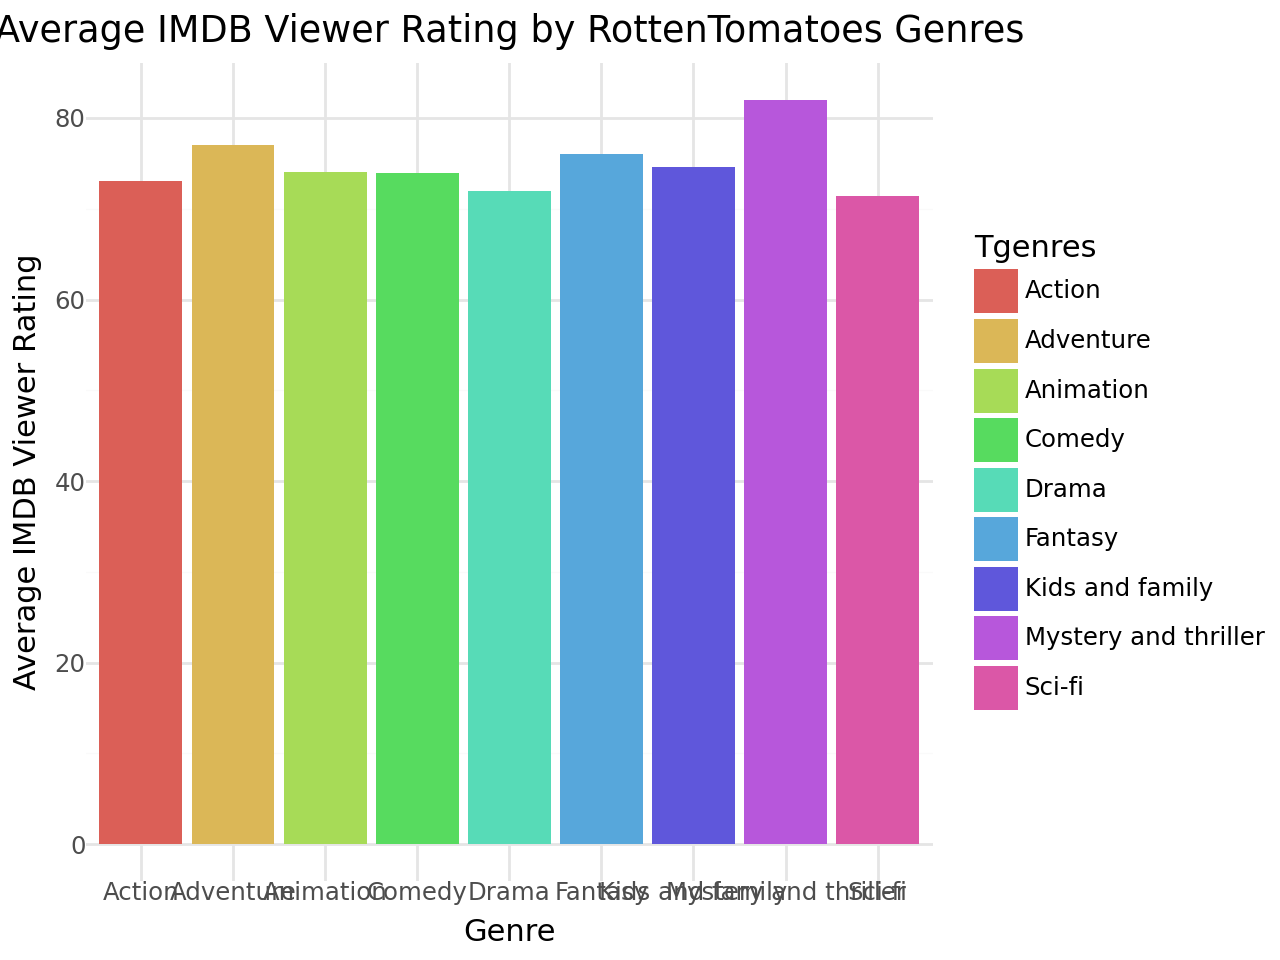

In [ ]:
barplot = ggplot(df_filtered, aes(x='Tgenres', y='ImdbViewerRating',fill='Tgenres')) + \
          stat_summary(fun_y=np.mean, geom='bar') + \
          theme_minimal() + \
          labs(x="Genre", y="Average IMDB Viewer Rating", title='Average IMDB Viewer Rating by RottenTomatoes Genres')
barplot

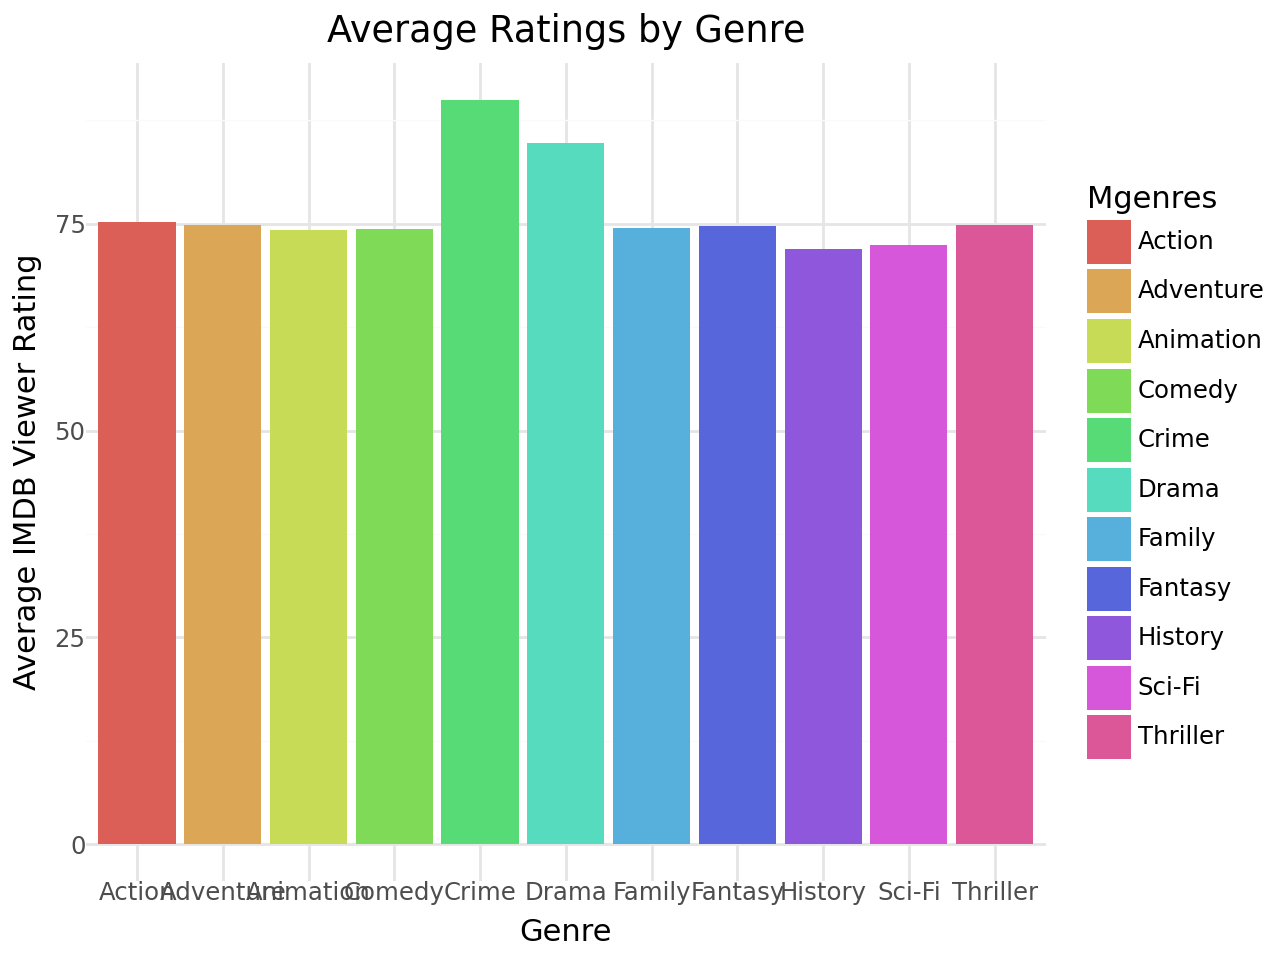

In [ ]:
barplot = ggplot(df_filtered, aes(x='Mgenres', y='ImdbViewerRating',fill='Mgenres')) + \
          stat_summary(fun_y=np.mean, geom='bar') + \
          theme_minimal() + \
          labs(x="Genre", y="Average IMDB Viewer Rating", title='Average Ratings by Genre')
barplot